## Pandas :
extremely powerful version of excel in python, with more functionality
Raw Data ----> Import to pandas -----> Analyze, Manipulate, Process, Do the data sciemce
-- Series

-- DataFrames

-- Data manipulation

-- Data I/O

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [4]:
por = np.array([.34,.51,.23,.63])

## Series

In [7]:
por_series = pd.Series(data=por, index = ['a','b','c','d']) #Here we have customized labels or index for porosity series 

In [8]:
por_series

a    0.34
b    0.51
c    0.23
d    0.63
dtype: float64

In [9]:
perm = {'rockA':0.54, 'rockB':0.34,'rockC':0.24}

In [12]:
perm_series = pd.Series(data = perm, name = 'Permeabilities')

<AxesSubplot:>

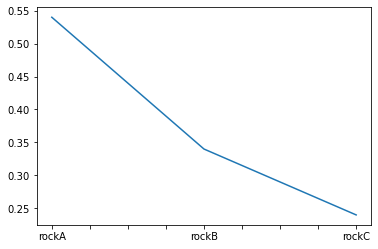

In [14]:
perm_series.plot()

## Dataframes: bunch of series together having same index

In [18]:
depth_index = [1000,1500,2000,2500]
por_series1 = pd.Series(data = [.10,.16,.23,.45], index = depth_index)
por_series2 = pd.Series(data = [.15,.17,.20,.54], index = depth_index)

In [21]:
pd.DataFrame([por_series1, por_series2]).T  #.T is transpose function

,0,1
1000,0.10,0.15
1500,0.16,0.17
2000,0.23,0.20
2500,0.45,0.54


In [22]:
## dataframe using dictionary

my_field_data = {'depth':[1000, 1500, 2000], 'poro(%)':[35, 30, 25], 'Perm(mD)':[500, 450, 150]}

In [23]:
field_data_df = pd.DataFrame(my_field_data)

In [24]:
field_data_df

,depth,poro(%),Perm(mD)
0,1000,35,500
1,1500,30,450
2,2000,25,150


<AxesSubplot:>

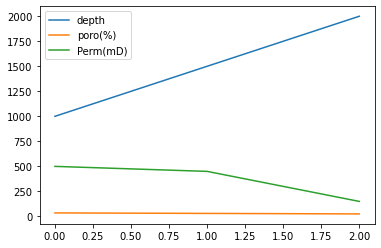

In [25]:
field_data_df.plot()

array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object)

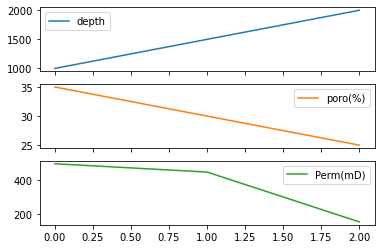

In [26]:
field_data_df.plot(subplots = True)  #To plot multiple data in subplots 

### Accessing Columns

In [27]:
field_data_df['depth']

0    1000
1    1500
2    2000
Name: depth, dtype: int64

In [30]:
type(field_data_df['depth'])

pandas.core.series.Series

In [33]:
field_data_df[['depth']]   #With double bracket it extracts the column as a Dataframe instead of Series

,depth
0,1000
1,1500
2,2000


In [34]:
type(field_data_df[['depth']])

pandas.core.frame.DataFrame

In [36]:
field_data_df.index = field_data_df['depth']  #Now the depth is made the index of this Dataframe

In [37]:
field_data_df

,depth,poro(%),Perm(mD)
depth,,,
1000,1000,35,500
1500,1500,30,450
2000,2000,25,150


### Accessing Rows from DataFrame

loc = index label
iloc= index number

The rows can be accessed usign both index name or index number

In [39]:
field_data_df.loc[1500]

depth       1500
poro(%)       30
Perm(mD)     450
Name: 1500, dtype: int64

In [40]:
field_data_df.iloc[1]

depth       1500
poro(%)       30
Perm(mD)     450
Name: 1500, dtype: int64

#### Creating a array of multiple dataset using arrange and linspace

In [70]:
depth = np.arange(1000,6000,500)

porosity = np.linspace(40,10,10)

perm = np.linspace(500,100,10)

reservoir_pressure = np.linspace(3000,4500,10)

In [71]:
df = pd.DataFrame({'depth': depth, 'porosity': porosity, 'Perm': perm, 'Rpress': reservoir_pressure})  
#Converting the above data into Dataframe

In [72]:
df.index= df['depth']

In [73]:
df

,depth,porosity,Perm,Rpress
depth,,,,
1000,1000,40.000000,500.000000,3000.000000
1500,1500,36.666667,455.555556,3166.666667
2000,2000,33.333333,411.111111,3333.333333
2500,2500,30.000000,366.666667,3500.000000
3000,3000,26.666667,322.222222,3666.666667
3500,3500,23.333333,277.777778,3833.333333
4000,4000,20.000000,233.333333,4000.000000
4500,4500,16.666667,188.888889,4166.666667
5000,5000,13.333333,144.444444,4333.333333


In [74]:
df.loc[1500:4000]

,depth,porosity,Perm,Rpress
depth,,,,
1500,1500,36.666667,455.555556,3166.666667
2000,2000,33.333333,411.111111,3333.333333
2500,2500,30.000000,366.666667,3500.000000
3000,3000,26.666667,322.222222,3666.666667
3500,3500,23.333333,277.777778,3833.333333
4000,4000,20.000000,233.333333,4000.000000


In [75]:
df.iloc[1:6]   #Here in iloc last index value is not included

,depth,porosity,Perm,Rpress
depth,,,,
1500,1500,36.666667,455.555556,3166.666667
2000,2000,33.333333,411.111111,3333.333333
2500,2500,30.000000,366.666667,3500.000000
3000,3000,26.666667,322.222222,3666.666667
3500,3500,23.333333,277.777778,3833.333333


In [76]:
df.iloc[1:6][['porosity', 'Perm']]   
#Here we have accessed particular rows and columns both, [[]] used for extracting multiple columns as a DataFrame

,porosity,Perm
depth,,
1500,36.666667,455.555556
2000,33.333333,411.111111
2500,30.000000,366.666667
3000,26.666667,322.222222
3500,23.333333,277.777778


## Adding new column in the DataFrame

In [77]:
df["WaterSaturation"] = np.linspace(.5,.9,10)

In [78]:
df

,depth,porosity,Perm,Rpress,WaterSaturation
depth,,,,,
1000,1000,40.000000,500.000000,3000.000000,0.500000
1500,1500,36.666667,455.555556,3166.666667,0.544444
2000,2000,33.333333,411.111111,3333.333333,0.588889
2500,2500,30.000000,366.666667,3500.000000,0.633333
3000,3000,26.666667,322.222222,3666.666667,0.677778
3500,3500,23.333333,277.777778,3833.333333,0.722222
4000,4000,20.000000,233.333333,4000.000000,0.766667
4500,4500,16.666667,188.888889,4166.666667,0.811111
5000,5000,13.333333,144.444444,4333.333333,0.855556


In [79]:
df["Saturation*Porosity/Permeability"] = df["WaterSaturation"]*df["porosity"]/df["Perm"]

In [80]:
df

,depth,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability
depth,,,,,,
1000,1000,40.000000,500.000000,3000.000000,0.500000,0.040000
1500,1500,36.666667,455.555556,3166.666667,0.544444,0.043821
2000,2000,33.333333,411.111111,3333.333333,0.588889,0.047748
2500,2500,30.000000,366.666667,3500.000000,0.633333,0.051818
3000,3000,26.666667,322.222222,3666.666667,0.677778,0.056092
3500,3500,23.333333,277.777778,3833.333333,0.722222,0.060667
4000,4000,20.000000,233.333333,4000.000000,0.766667,0.065714
4500,4500,16.666667,188.888889,4166.666667,0.811111,0.071569
5000,5000,13.333333,144.444444,4333.333333,0.855556,0.078974


## Dropping the Data in DataFrame

In [81]:
df = df.drop("depth",axis =1)
#We have to assign the new Dataframe to something to update it like here df = df.drop

#### Axis = 1, then whole column will drop the python will look into columns
#### Axis = 0, then whole row will drop the python will look into particular rows

In [82]:
df

,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability
depth,,,,,
1000,40.000000,500.000000,3000.000000,0.500000,0.040000
1500,36.666667,455.555556,3166.666667,0.544444,0.043821
2000,33.333333,411.111111,3333.333333,0.588889,0.047748
2500,30.000000,366.666667,3500.000000,0.633333,0.051818
3000,26.666667,322.222222,3666.666667,0.677778,0.056092
3500,23.333333,277.777778,3833.333333,0.722222,0.060667
4000,20.000000,233.333333,4000.000000,0.766667,0.065714
4500,16.666667,188.888889,4166.666667,0.811111,0.071569
5000,13.333333,144.444444,4333.333333,0.855556,0.078974


In [83]:
df.drop(3000,axis =0)

#Now here the row with depth or index 3000 is dropped but not saved

,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability
depth,,,,,
1000,40.000000,500.000000,3000.000000,0.500000,0.040000
1500,36.666667,455.555556,3166.666667,0.544444,0.043821
2000,33.333333,411.111111,3333.333333,0.588889,0.047748
2500,30.000000,366.666667,3500.000000,0.633333,0.051818
3500,23.333333,277.777778,3833.333333,0.722222,0.060667
4000,20.000000,233.333333,4000.000000,0.766667,0.065714
4500,16.666667,188.888889,4166.666667,0.811111,0.071569
5000,13.333333,144.444444,4333.333333,0.855556,0.078974
5500,10.000000,100.000000,4500.000000,0.900000,0.090000


In [84]:
df

,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability
depth,,,,,
1000,40.000000,500.000000,3000.000000,0.500000,0.040000
1500,36.666667,455.555556,3166.666667,0.544444,0.043821
2000,33.333333,411.111111,3333.333333,0.588889,0.047748
2500,30.000000,366.666667,3500.000000,0.633333,0.051818
3000,26.666667,322.222222,3666.666667,0.677778,0.056092
3500,23.333333,277.777778,3833.333333,0.722222,0.060667
4000,20.000000,233.333333,4000.000000,0.766667,0.065714
4500,16.666667,188.888889,4166.666667,0.811111,0.071569
5000,13.333333,144.444444,4333.333333,0.855556,0.078974


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10 entries, 1000 to 5500
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   porosity                          10 non-null     float64
 1   Perm                              10 non-null     float64
 2   Rpress                            10 non-null     float64
 3   WaterSaturation                   10 non-null     float64
 4   Saturation*Porosity/Permeability  10 non-null     float64
dtypes: float64(5)
memory usage: 780.0 bytes


In [87]:
df.head()  #Shows the first 5 rows of your data

,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability
depth,,,,,
1000,40.000000,500.000000,3000.000000,0.500000,0.040000
1500,36.666667,455.555556,3166.666667,0.544444,0.043821
2000,33.333333,411.111111,3333.333333,0.588889,0.047748
2500,30.000000,366.666667,3500.000000,0.633333,0.051818
3000,26.666667,322.222222,3666.666667,0.677778,0.056092


In [89]:
df.describe()  #Gives the statistics of your data

,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,25.000000,300.000000,3750.000000,0.700000,0.060640
std,10.092168,134.562238,504.608392,0.134562,0.016045
min,10.000000,100.000000,3000.000000,0.500000,0.040000
25%,17.500000,200.000000,3375.000000,0.600000,0.048765
50%,25.000000,300.000000,3750.000000,0.700000,0.058379
75%,32.500000,400.000000,4125.000000,0.800000,0.070105
max,40.000000,500.000000,4500.000000,0.900000,0.090000


## Conditional Selection of the data

In [90]:
df["Lithology"] = np.random.choice(["Sandstone","Limestone","Shale"],size = (10,))

#Here we are adding new column named Lithology and assigning random values to each rows using random.choice

In [91]:
df

,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability,Lithology
depth,,,,,,
1000,40.000000,500.000000,3000.000000,0.500000,0.040000,Shale
1500,36.666667,455.555556,3166.666667,0.544444,0.043821,Shale
2000,33.333333,411.111111,3333.333333,0.588889,0.047748,Sandstone
2500,30.000000,366.666667,3500.000000,0.633333,0.051818,Limestone
3000,26.666667,322.222222,3666.666667,0.677778,0.056092,Sandstone
3500,23.333333,277.777778,3833.333333,0.722222,0.060667,Shale
4000,20.000000,233.333333,4000.000000,0.766667,0.065714,Sandstone
4500,16.666667,188.888889,4166.666667,0.811111,0.071569,Shale
5000,13.333333,144.444444,4333.333333,0.855556,0.078974,Sandstone


In [92]:
df['Lithology'] == 'Shale'

depth
1000     True
1500     True
2000    False
2500    False
3000    False
3500     True
4000    False
4500     True
5000    False
5500    False
Name: Lithology, dtype: bool

In [93]:
df[df['Lithology'] == 'Shale']

#The above condition is put into the dataframe to get conditional rows

,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability,Lithology
depth,,,,,,
1000,40.000000,500.000000,3000.000000,0.500000,0.040000,Shale
1500,36.666667,455.555556,3166.666667,0.544444,0.043821,Shale
3500,23.333333,277.777778,3833.333333,0.722222,0.060667,Shale
4500,16.666667,188.888889,4166.666667,0.811111,0.071569,Shale


In [94]:
df['porosity']>20

depth
1000     True
1500     True
2000     True
2500     True
3000     True
3500     True
4000    False
4500    False
5000    False
5500    False
Name: porosity, dtype: bool

In [97]:
df[(df['porosity']>20) & (df['Lithology'] != 'Shale')]

#Multiple conditions in a same statement. We have to write all conditions inside df (dataframe only)

,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability,Lithology
depth,,,,,,
2000,33.333333,411.111111,3333.333333,0.588889,0.047748,Sandstone
2500,30.000000,366.666667,3500.000000,0.633333,0.051818,Limestone
3000,26.666667,322.222222,3666.666667,0.677778,0.056092,Sandstone


## Exporting the data to any form

In [98]:
df.to_csv("field_properties.csv")

### Importing the csv file or reading the new file

In [100]:
df_read = pd.read_csv('field_properties.csv')

In [101]:
df_read

,depth,porosity,Perm,Rpress,WaterSaturation,Saturation*Porosity/Permeability,Lithology
0,1000,40.000000,500.000000,3000.000000,0.500000,0.040000,Shale
1,1500,36.666667,455.555556,3166.666667,0.544444,NaN,Shale
2,2000,33.333333,411.111111,3333.333333,0.588889,0.047748,Sandstone
3,2500,30.000000,366.666667,3500.000000,0.633333,0.051818,NaN
4,3000,26.666667,322.222222,NaN,0.677778,0.056092,Sandstone
5,3500,23.333333,277.777778,3833.333333,0.722222,0.060667,Shale
6,4000,20.000000,NaN,4000.000000,0.766667,NaN,Sandstone
7,4500,16.666667,188.888889,4166.666667,NaN,0.071569,Shale
8,5000,13.333333,144.444444,4333.333333,0.855556,0.078974,Sandstone
9,5500,10.000000,100.000000,4500.000000,0.900000,0.090000,Sandstone


In [103]:
df_read.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   depth                             10 non-null     int64  
 1   porosity                          10 non-null     float64
 2   Perm                              9 non-null      float64
 3   Rpress                            9 non-null      float64
 4   WaterSaturation                   9 non-null      float64
 5   Saturation*Porosity/Permeability  8 non-null      float64
 6   Lithology                         9 non-null      object 
dtypes: float64(5), int64(1), object(1)
memory usage: 688.0+ bytes
